# Automated wildlife identification from ALA camera-trap images using SpeciesNet

**Authors:** Renuka Sharma  
**Data source:** [Atlas of Living Australia (ALA)](https://www.ala.org.au/) | **Model:** [SpeciesNet by Google](https://github.com/google/cameratrapai)

---

Wildlife monitoring at scale is one of ecology's most data-intensive challenges. Camera traps deployed across remote landscapes can accumulate thousands of images in a single survey season — far more than any team can manually review in a reasonable time. Automatically identifying the species in each photograph would free researchers to focus on analysis rather than image sorting, but doing this accurately requires a model trained on a large and diverse set of wildlife images.

This notebook shows how to combine two open tools to tackle this problem: the [Atlas of Living Australia (ALA)](https://www.ala.org.au/) — Australia's national biodiversity data platform — and [SpeciesNet](https://github.com/google/cameratrapai), a deep learning model developed by Google specifically for wildlife image classification. We query ALA for camera-trap images of target species, download a sample, run SpeciesNet to automatically identify animals in each image, and then visualise the results.

By the end of this notebook you will be able to:
- retrieve camera-trap image metadata from ALA using `galah-python`
- run automated species identification with SpeciesNet
- interpret the model's predictions and understand when to trust them

> **Note:** Run cells from top to bottom in order. All required packages are installed in the **Setup** cell below.

## Setup

Install the required Python packages. **Run this cell once at the start of every session** — packages are not persisted between sessions.

| Package | Purpose |
|---|---|
| `pandas` | Organising, cleaning, and analysing tabular data |
| `galah-python` | Querying and downloading biodiversity records from ALA |
| `requests` | Retrieving image data from URLs |
| `speciesnet` | Running the wildlife detection and classification model |
| `Pillow` | Opening, resizing, and annotating images |

> **Tip:** If you see an error after installing (e.g. a version conflict), please re-run from this cell.

In [8]:
! pip install pandas galah-python requests speciesnet Pillow --quiet

## Imports

Import standard libraries and define a utility function used later to manage the image download folder. SpeciesNet-specific imports are deferred to the **Run SpeciesNet** section so that this cell runs quickly even before the model weights are downloaded.

In [2]:
import os
import time
import math
import pickle
import shutil
from pathlib import Path

import pandas as pd
import requests
import matplotlib.pyplot as plt
%matplotlib inline
from PIL import Image


def empty_directory(directory: Path):
    """Delete all files and sub-directories inside *directory* without
    removing the directory itself.  Creates it if it does not yet exist."""
    if not directory.exists():
        directory.mkdir(parents=True)
        return
    for item in directory.iterdir():
        if item.is_file() or item.is_symlink():
            item.unlink()
        elif item.is_dir():
            shutil.rmtree(item)

## Download data from ALA

The [Atlas of Living Australia (ALA)](https://www.ala.org.au/) is Australia's national biodiversity data infrastructure, aggregating over 130 million occurrence records from museums, herbaria, citizen science platforms (e.g. iNaturalist), and government surveys. Many of these records include photographs taken in the field — including images from camera-trap deployments — which is exactly what we need to test SpeciesNet.

We use the `galah-python` package to query ALA's API and retrieve image metadata for our target species.

### Configure galah

`galah` requires a registered ALA email address to submit download requests. Registration is free at [ala.org.au](https://www.ala.org.au/). Replace the placeholder email below with your own. You can also change the `taxa` list to any species you are interested in — use the scientific (Latin) name.

In [24]:
import galah

galah.galah_config(
    atlas="Australia",
    # email="your-email@example.com",   # ← replace with your ALA-registered email
    email="renuka.sharma@qcif.edu.au",   # ← replace with your ALA-registered email
)
print("galah config applied.")

# Species to query — use scientific (Latin) names
# You can add or remove species from this list, keep it under 3 for ease of processing at this stage
# taxa = ['Felis catus', 'Sus scrofa', 'Canis dingo']
taxa = ['Felis catus', 'Sus scrofa']

print(f"\nQuerying {len(taxa)} species:")
for i, sp in enumerate(taxa, 1):
    print(f"  {i}. {sp}")

galah config applied.

Querying 2 species:
  1. Felis catus
  2. Sus scrofa


### Check record counts

Before fetching full metadata, it is worth checking how many image records exist for your taxa and geographic filter. This is a fast call that does not trigger a download — it gives you a sense of dataset size so you can decide whether to narrow your filters further. The cell below returns a count broken down by media type.

In [25]:
galah.atlas_counts(
    taxa=taxa,
    filters=['stateProvince=Queensland'],
    group_by="multimedia"
)

,multimedia,count
0,Image,3333


### Fetch image metadata

Now we retrieve the full image metadata using `galah.atlas_media()`. This returns a table of records that includes the image URL, species name, data-resource name, and observation coordinates for every matching record. Crucially, setting `collect=False` means we are only downloading the metadata — not the image files themselves, which we will do in a later step.

This call submits a download job to ALA's servers and polls until it is ready, which can take a few minutes for large result sets. Adding `year` and `month` filters (as below) significantly reduces the wait time. Our test run with Queensland, December 2022 completed in about 2.5 minutes.

> **Note for Google Colab users:** ALA's download service occasionally blocks requests from cloud provider IP addresses, returning a `JSONDecodeError` or `403 Forbidden`. If you encounter this, try re-running the cell. If it persists, run this cell locally, save the result with `media_df.to_csv("media_df.csv")`, then upload that file to Colab and load it with `media_df = pd.read_csv("media_df.csv")`.

In [26]:
media_df = galah.atlas_media(
    taxa=taxa,
    filters=["stateProvince=Queensland", "year=2023", "month=1"],  # narrow filters = faster
    multimedia="images",
    collect=False,   # metadata only — image files are NOT downloaded here
)

print(f"Retrieved {len(media_df)} image records.")
media_df.head()

Retrieved 577 image records.


,decimalLatitude,decimalLongitude,eventDate,scientificName,taxonConceptID,recordID,dataResourceName,occurrenceStatus,videos,videos,...,multimedia,images,videos,sounds,creator,license,mimeType,width,height,imageUrl
0,-17.289829,145.795254,2023-01-05T00:00:00Z,Sus scrofa,https://biodiversity.org.au/afd/taxa/948d8ca1-...,7a8dcbfb-13d5-48a2-b68a-5c6e7f300374,Camera trap surveys in Queensland's Wet Tropic...,PRESENT,NaN,NaN,...,Image,a173c683-be6b-41a3-bd1d-b6b25e1febca,NaN,NaN,,,image/jpeg,5376,3024,https://images.ala.org.au/store/a/c/b/e/a173c6...
1,-17.298442,145.802244,2023-01-12T00:00:00Z,Sus scrofa,https://biodiversity.org.au/afd/taxa/948d8ca1-...,4059429b-063e-4d8a-9c0a-7394f68d883b,Camera trap surveys in Queensland's Wet Tropic...,PRESENT,NaN,NaN,...,Image,091ec310-6269-4169-8a81-c61356986215,NaN,NaN,,,image/jpeg,5376,3024,https://images.ala.org.au/store/5/1/2/6/091ec3...
2,-17.298442,145.802244,2023-01-08T00:00:00Z,Sus scrofa,https://biodiversity.org.au/afd/taxa/948d8ca1-...,85c56b37-7b14-4e19-800c-739d1cab2d8b,Camera trap surveys in Queensland's Wet Tropic...,PRESENT,NaN,NaN,...,Image,467114e8-8b17-4bc3-b3b5-9d641bb59935,NaN,NaN,,,image/jpeg,5376,3024,https://images.ala.org.au/store/5/3/9/9/467114...
3,-17.298442,145.802244,2023-01-25T00:00:00Z,Sus scrofa,https://biodiversity.org.au/afd/taxa/948d8ca1-...,5e0eca85-19b6-4a7d-9d6e-b0be282aaa4b,Camera trap surveys in Queensland's Wet Tropic...,PRESENT,NaN,NaN,...,Image,e728ad63-f366-482d-9861-004f764d6313,NaN,NaN,,,image/jpeg,5376,3024,https://images.ala.org.au/store/3/1/3/6/e728ad...
4,-17.289829,145.795254,2023-01-19T00:00:00Z,Sus scrofa,https://biodiversity.org.au/afd/taxa/948d8ca1-...,91e87fb1-5336-496c-91c6-49bbe3edcae6,Camera trap surveys in Queensland's Wet Tropic...,PRESENT,NaN,NaN,...,Image,6a96467c-eb69-4b0d-b5af-122ffe595915,NaN,NaN,,,image/jpeg,5376,3024,https://images.ala.org.au/store/5/1/9/5/6a9646...


### Inspect the data

Before filtering, take a look at what data resources and species came back. ALA aggregates records from many different providers, and the quality and type of images varies considerably between them. Knowing which datasets are present lets you make an informed decision about which ones to keep.

In [27]:
print("Columns:", media_df.columns.tolist())
print("\nUnique data resources:")
for dr in media_df['dataResourceName'].unique():
    print(" •", dr)
print("\nUnique scientific names:")
for sp in media_df['scientificName'].unique():
    print(" •", sp)

Columns: ['decimalLatitude', 'decimalLongitude', 'eventDate', 'scientificName', 'taxonConceptID', 'recordID', 'dataResourceName', 'occurrenceStatus', 'videos', 'videos', 'videos', 'videos', 'videos', 'videos', 'videos', 'multimedia', 'images', 'videos', 'sounds', 'creator', 'license', 'mimeType', 'width', 'height', 'imageUrl']

Unique data resources:
 • Camera trap surveys in Queensland's Wet Tropics 2022-2023
 • iNaturalist Australia

Unique scientific names:
 • Sus scrofa
 • Felis catus


### Filter to camera-trap datasets

Not all ALA image records are equally suitable for SpeciesNet. The model was trained on camera-trap images and performs best on that type of photograph. Field photos, museum specimens, or heavily cropped images can produce unreliable predictions. Here we restrict the data to records from the [Wildlife Observatories of Australia (WildObs)](https://collections.ala.org.au/public/show/dr33008) dataset, which contains high-quality, labelled camera-trap images, and keep only our two target species.

Update `values_to_keep` with the dataset names you saw in the previous cell, and adjust `target_species` to match your taxa of interest.

In [28]:
values_to_keep = [
    "Camera trap surveys in Queensland's Wet Tropics 2022-2023",
    "Monitoring many landscapes in VIC-NSW border to assess impacts of 2019-20 gigafires on wildlife diel activity",
    "Wombat burrows are hotspots for small vertebrates in a landscape subject to gigafire",
]
target_species = ['Felis catus', 'Sus scrofa', 'Canis dingo']

filtered_df = media_df[
    media_df["dataResourceName"].isin(values_to_keep) &
    media_df["scientificName"].isin(target_species)
]

print(f"Records after filtering: {len(filtered_df)}")
filtered_df.head()

Records after filtering: 576


,decimalLatitude,decimalLongitude,eventDate,scientificName,taxonConceptID,recordID,dataResourceName,occurrenceStatus,videos,videos,...,multimedia,images,videos,sounds,creator,license,mimeType,width,height,imageUrl
0,-17.289829,145.795254,2023-01-05T00:00:00Z,Sus scrofa,https://biodiversity.org.au/afd/taxa/948d8ca1-...,7a8dcbfb-13d5-48a2-b68a-5c6e7f300374,Camera trap surveys in Queensland's Wet Tropic...,PRESENT,NaN,NaN,...,Image,a173c683-be6b-41a3-bd1d-b6b25e1febca,NaN,NaN,,,image/jpeg,5376,3024,https://images.ala.org.au/store/a/c/b/e/a173c6...
1,-17.298442,145.802244,2023-01-12T00:00:00Z,Sus scrofa,https://biodiversity.org.au/afd/taxa/948d8ca1-...,4059429b-063e-4d8a-9c0a-7394f68d883b,Camera trap surveys in Queensland's Wet Tropic...,PRESENT,NaN,NaN,...,Image,091ec310-6269-4169-8a81-c61356986215,NaN,NaN,,,image/jpeg,5376,3024,https://images.ala.org.au/store/5/1/2/6/091ec3...
2,-17.298442,145.802244,2023-01-08T00:00:00Z,Sus scrofa,https://biodiversity.org.au/afd/taxa/948d8ca1-...,85c56b37-7b14-4e19-800c-739d1cab2d8b,Camera trap surveys in Queensland's Wet Tropic...,PRESENT,NaN,NaN,...,Image,467114e8-8b17-4bc3-b3b5-9d641bb59935,NaN,NaN,,,image/jpeg,5376,3024,https://images.ala.org.au/store/5/3/9/9/467114...
3,-17.298442,145.802244,2023-01-25T00:00:00Z,Sus scrofa,https://biodiversity.org.au/afd/taxa/948d8ca1-...,5e0eca85-19b6-4a7d-9d6e-b0be282aaa4b,Camera trap surveys in Queensland's Wet Tropic...,PRESENT,NaN,NaN,...,Image,e728ad63-f366-482d-9861-004f764d6313,NaN,NaN,,,image/jpeg,5376,3024,https://images.ala.org.au/store/3/1/3/6/e728ad...
4,-17.289829,145.795254,2023-01-19T00:00:00Z,Sus scrofa,https://biodiversity.org.au/afd/taxa/948d8ca1-...,91e87fb1-5336-496c-91c6-49bbe3edcae6,Camera trap surveys in Queensland's Wet Tropic...,PRESENT,NaN,NaN,...,Image,6a96467c-eb69-4b0d-b5af-122ffe595915,NaN,NaN,,,image/jpeg,5376,3024,https://images.ala.org.au/store/5/1/9/5/6a9646...


### Select a sample

Running SpeciesNet on hundreds of images can take a long time, especially without a GPU. For now, we randomly select a small subset to keep things manageable. Once you are comfortable with the workflow, you can increase `N_IMAGES` or remove the sampling step entirely to process the full filtered dataset. Setting `random_state=42` ensures the same images are chosen every time you run the cell, which is useful for reproducibility.

In [29]:
N_IMAGES = 6  # number of images to download

subset_df = filtered_df.sample(min(N_IMAGES, len(filtered_df)), random_state=42)
print(f"Subset size: {len(subset_df)}")
subset_df[["scientificName", "dataResourceName", "imageUrl"]].reset_index(drop=True)

Subset size: 6


,scientificName,dataResourceName,imageUrl
0,Sus scrofa,Camera trap surveys in Queensland's Wet Tropic...,https://images.ala.org.au/store/2/3/3/7/33e844...
1,Sus scrofa,Camera trap surveys in Queensland's Wet Tropic...,https://images.ala.org.au/store/a/b/e/e/242c36...
2,Sus scrofa,Camera trap surveys in Queensland's Wet Tropic...,https://images.ala.org.au/store/2/5/7/e/19c872...
3,Sus scrofa,Camera trap surveys in Queensland's Wet Tropic...,https://images.ala.org.au/store/8/c/f/8/5e4e30...
4,Sus scrofa,Camera trap surveys in Queensland's Wet Tropic...,https://images.ala.org.au/store/b/e/f/f/75dd5c...
5,Sus scrofa,Camera trap surveys in Queensland's Wet Tropic...,https://images.ala.org.au/store/f/0/7/7/8e336e...


### Download images

Now we download the actual image files from their ALA-hosted URLs and save them to the `EC_images` folder. The folder is cleared at the start of each run so that images from a previous run do not accumulate. Each file is named after its DataFrame row index (e.g. `144.jpg`), making it straightforward to trace a prediction back to the original metadata record.

In [30]:
image_folder = Path("EC_images")
empty_directory(image_folder)   # clears the folder (or creates it if new)

for i, row in subset_df.iterrows():
    url = row["imageUrl"]
    filename = image_folder / f"{i}.jpg"
    try:
        r = requests.get(url, timeout=30)
        r.raise_for_status()
        filename.write_bytes(r.content)
        print(f"Downloaded: {filename.name}")
    except Exception as e:
        print(f"Failed to download {url}: {e}")

print(f"\nDone. {len(list(image_folder.glob('*.jpg')))} images saved to '{image_folder}'.")

Downloaded: 235.jpg
Downloaded: 118.jpg
Downloaded: 347.jpg
Downloaded: 499.jpg
Downloaded: 403.jpg
Downloaded: 401.jpg

Done. 6 images saved to 'EC_images'.


### Preview the images

Before running the model, display the downloaded images as a grid to confirm they look as expected. This is a good moment to spot any blank frames, setup photos, or corrupted files that might produce unreliable predictions and should be excluded before analysis.

Found 6 images.


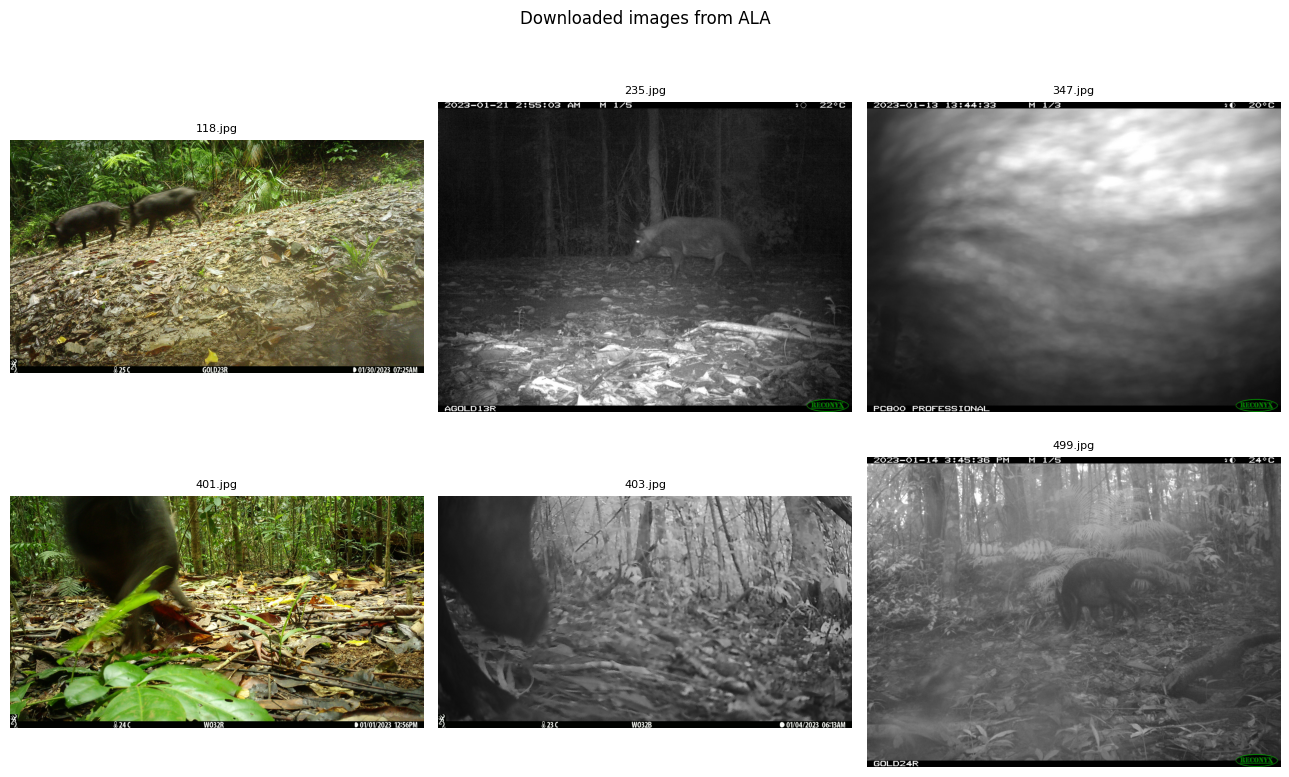

In [31]:
image_paths = sorted(image_folder.glob("*.jpg"))
print(f"Found {len(image_paths)} images.")

n_show = min(6, len(image_paths))
fig, axes = plt.subplots(2, 3, figsize=(13, 8))

for ax, img_path in zip(axes.flatten(), image_paths[:n_show]):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(img_path.name, fontsize=8)
    ax.axis("off")

# Hide unused subplot panels
for ax in axes.flatten()[n_show:]:
    ax.set_visible(False)

plt.suptitle("Downloaded images from ALA", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Run SpeciesNet

[SpeciesNet](https://github.com/google/cameratrapai) is a deep learning model developed by Google for automated wildlife identification in camera-trap images. It was trained on over 65 million camera-trap images from the [Wildlife Insights](https://www.wildlifeinsights.org/) platform, making it one of the most extensively trained wildlife classifiers available.

The model works in two stages. First, a **detector** scans the image and draws a bounding box around any animal it finds, along with a confidence score (0–1) indicating how certain it is that an animal is present. Second, a **classifier** examines the content inside the bounding box — or the full image if no box was found — and assigns the most likely species label from a vocabulary of over 2,000 labels. These labels span individual species (e.g. *Sus scrofa*, wild boar), broader taxonomic groups (e.g. `"felidae"`, cat family), and non-animal classes (`"blank"`, `"vehicle"`, `"human"`).

### Geofencing

SpeciesNet includes a **geofencing** step that filters out predictions for species known not to occur in a given country. For example, if you supply `country="AUS"`, the model will not predict "lion" or "elephant" for an Australian image, even if the raw classifier score for those labels is high. Geofencing is enabled by default and is strongly recommended whenever you are working within a defined geographic region — it meaningfully reduces false positives.

### Load libraries

Import the SpeciesNet library and define a small helper function that prints predictions in a readable format. We also print the available models — `DEFAULT_MODEL` is the recommended choice for most use cases.

In [32]:
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display, JSON

from speciesnet import DEFAULT_MODEL, SUPPORTED_MODELS
from speciesnet import draw_bboxes, load_rgb_image, SpeciesNet


def print_predictions(predictions_dict: dict) -> None:
    """Print a human-readable summary of SpeciesNet predictions."""
    print("Predictions:")
    for pred in predictions_dict["predictions"]:
        print(f"  {Path(pred['filepath']).name}  =>  {pred['prediction']}")


print("Default model :", DEFAULT_MODEL)
print("Supported models:", SUPPORTED_MODELS)

Default model : kaggle:google/speciesnet/pyTorch/v4.0.1a
Supported models: ['kaggle:google/speciesnet/pyTorch/v4.0.1a', 'kaggle:google/speciesnet/pyTorch/v4.0.1b']


### Load the model

The cell below loads SpeciesNet. The first time it runs, it will download the model weights (approximately 1–2 GB), which can take a few minutes. Subsequent runs in the same session use the cached weights instantly.

> **Tip for Colab users:** Colab's local disk is wiped when the runtime disconnects, so the weights will need to be re-downloaded each session. To avoid this, mount your Google Drive and point the cache there:
> ```python
> from google.colab import drive
> drive.mount('/content/drive')
> model = SpeciesNet(DEFAULT_MODEL, cache_dir="/content/drive/MyDrive/speciesnet_cache")
> ```

In [33]:
model = SpeciesNet(DEFAULT_MODEL)          # geofencing ON  (default)
# model = SpeciesNet(DEFAULT_MODEL, geofence=False)  # uncomment to disable geofencing
print("Model loaded.")

Model loaded.


### Run predictions

Pass the image folder to `model.predict()`. SpeciesNet will find every `.jpg`, `.jpeg`, and `.png` file in the folder, run the detector and classifier on each one, and return a dictionary of results — one entry per image.

In [34]:
predictions_dict = model.predict(folders=[image_folder])
print_predictions(predictions_dict)
# display(JSON(predictions_dict))  # uncomment for the full verbose output

Predictions:
  118.jpg  =>  d372cda5-a8ca-4b7b-97ed-4e4fab9c9b4b;mammalia;cetartiodactyla;suidae;sus;scrofa;wild boar
  235.jpg  =>  d372cda5-a8ca-4b7b-97ed-4e4fab9c9b4b;mammalia;cetartiodactyla;suidae;sus;scrofa;wild boar
  347.jpg  =>  aca65aaa-8c6d-4b69-94de-842b08b13bd6;mammalia;cetartiodactyla;bovidae;bos;taurus;domestic cattle
  401.jpg  =>  0f70fcca-5658-4f60-b0e4-48db3120cebc;mammalia;cetartiodactyla;suidae;sus;barbatus;bearded pig
  403.jpg  =>  797b2c80-4b99-45ec-b73f-5fd62bbb93a8;mammalia;cetartiodactyla;;;;cetartiodactyla order
  499.jpg  =>  f2d233e3-80e3-433d-9687-e29ecc7a467a;mammalia;;;;;mammal


**How to read a prediction string:**

Each prediction is a semicolon-separated string with 7 fields:

```
1b30ddf8-22fb-40ff-9df6-6a8a0b6ccaa1 ; mammalia ; monotremata ; tachyglossidae ; tachyglossus ; aculeatus ; short-beaked echidna

UUID; Class; Order; Family; Genus; Species; Common name
```

- **UUID** — unique label identifier in the SpeciesNet taxonomy
- **Class → Species** — full taxonomic hierarchy from class down to species epithet
- **Common name** — plain-language species name (last field, easiest to read)

If the model is not confident about a species, it may predict at a higher taxonomic level (e.g. `"felidae;;; cat family"` with blank genus/species fields).

### Run on specific files

Instead of a whole folder, you can pass a list of specific file paths. This is useful when you want to quickly test the model on a single image or a hand-picked selection without re-processing the entire folder.

In [35]:
image_paths = sorted(
    p for p in image_folder.iterdir()
    if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
)

predictions_dict = model.predict(filepaths=[image_paths[0], image_paths[1]])
print_predictions(predictions_dict)

Predictions:
  118.jpg  =>  d372cda5-a8ca-4b7b-97ed-4e4fab9c9b4b;mammalia;cetartiodactyla;suidae;sus;scrofa;wild boar
  235.jpg  =>  d372cda5-a8ca-4b7b-97ed-4e4fab9c9b4b;mammalia;cetartiodactyla;suidae;sus;scrofa;wild boar


### Visualise results

The cell below displays each image with its predictions overlaid. Where the detector found an animal, a red bounding box is drawn around it. The detector's confidence score appears in the top-left corner of the box (e.g. `animal: 0.94`), and the classifier's species label with its confidence score is shown in the bottom-right corner (e.g. `wild boar: 0.93`).

Where the detector found nothing — which can happen with blurry, fast-moving, or partially visible animals — the classifier's prediction is shown as a banner at the bottom of the image. The classifier still runs on the full image in these cases, so a species label is always produced.

File      : 118.jpg
Prediction: d372cda5-a8ca-4b7b-97ed-4e4fab9c9b4b;mammalia;cetartiodactyla;suidae;sus;scrofa;wild boar
  2 bounding box(es) drawn.



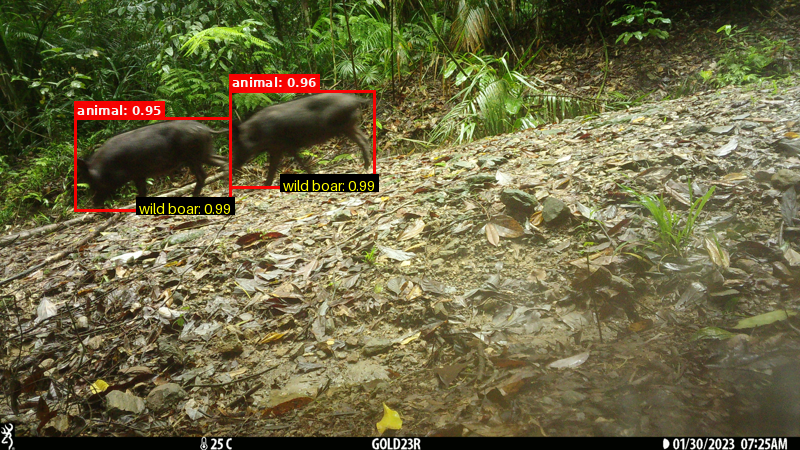

File      : 235.jpg
Prediction: d372cda5-a8ca-4b7b-97ed-4e4fab9c9b4b;mammalia;cetartiodactyla;suidae;sus;scrofa;wild boar
  1 bounding box(es) drawn.



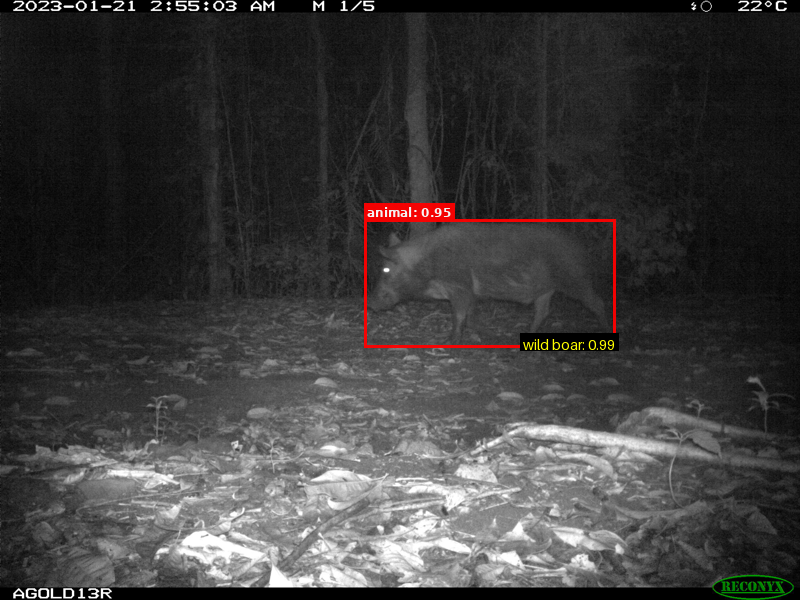

File      : 347.jpg
Prediction: aca65aaa-8c6d-4b69-94de-842b08b13bd6;mammalia;cetartiodactyla;bovidae;bos;taurus;domestic cattle
  2 bounding box(es) drawn.



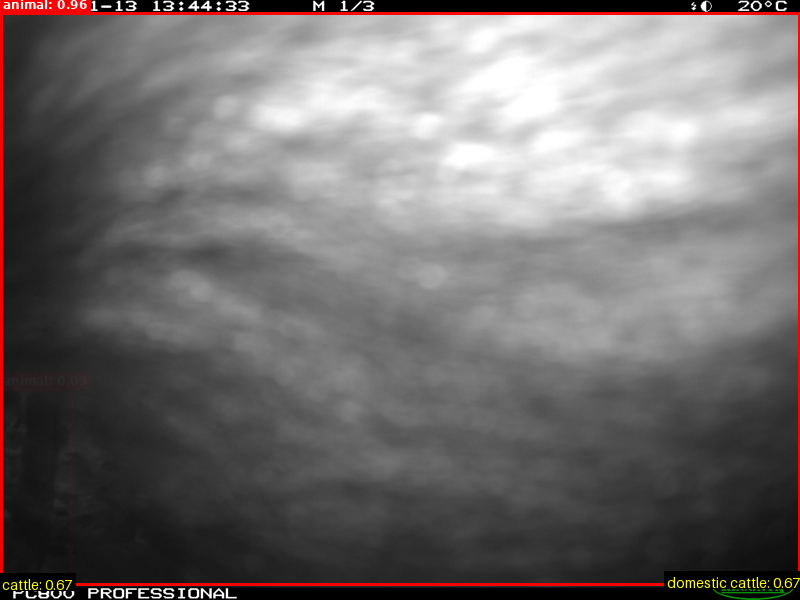

In [36]:
from PIL import ImageDraw, ImageFont

# Run SpeciesNet on all images in the folder
predictions_dict = model.predict(folders=[image_folder])

# Load a font 
font = ImageFont.load_default(size=14)  

n_show = min(3, len(predictions_dict["predictions"]))
for pred_item in predictions_dict["predictions"][:n_show]:
    fname      = Path(pred_item["filepath"]).name
    pred_text  = pred_item.get("prediction", "")
    detections = pred_item.get("detections", [])

    # The prediction string is semicolon-separated:
    # UUID ; class ; order ; family ; genus ; species ; common-name
    species_name = pred_text.split(";")[-1] if pred_text else "unknown"

    # Classifier confidence: classifications = {"classes": [...], "scores": [...]}
    # scores[0] is the top prediction's confidence (0–1)
    scores = pred_item.get("classifications", {}).get("scores", [])
    conf   = scores[0] if scores else None
    species_label = f"{species_name}: {conf:.2f}" if conf is not None else species_name

    print(f"File      : {fname}")
    print(f"Prediction: {pred_text}")

    img = load_rgb_image(pred_item["filepath"])
    img.thumbnail(size=(800, 800))

    if detections:
        # draw_bboxes draws a red box + "animal: conf" label for each detection.
        # It returns a NEW annotated image — the return value must be captured.
        img = draw_bboxes(img, detections)

        # Overlay the classifier's species label at the bottom-right of each box
        draw = ImageDraw.Draw(img)
        for det in detections:
            xmin, ymin, bw, bh = det["bbox"]
            x_right  = int((xmin + bw) * img.width)
            y_bottom = int((ymin + bh) * img.height)

            x1, y1, x2, y2 = draw.textbbox((0, 0), species_label, font=font)
            x_px = x_right  - (x2 - x1)   # right-align to box edge
            y_px = y_bottom - (y2 - y1)    # bottom-align to box edge

            draw.rectangle([x_px - 3, y_px - 3, x_right + 3, y_bottom + 3], fill=(0, 0, 0))
            draw.text((x_px, y_px), species_label, fill=(255, 255, 0), font=font)

        print(f"  {len(detections)} bounding box(es) drawn.")
    else:
        # No detection: the animal was not located above the detector's confidence
        # threshold (common with motion blur or partially visible subjects).
        # Draw the classifier result as a banner at the bottom of the image.
        draw = ImageDraw.Draw(img)
        w, h = img.size
        banner = f"Classifier: {species_label}  (no detection bbox)"
        draw.rectangle([0, h - 30, w, h], fill=(0, 0, 0))
        draw.text((6, h - 24), banner, fill=(255, 255, 255), font=font)
        print("  No bounding boxes — classifier label shown as banner.")

    print()
    display(img)

### Interpreting the results

**Confidence scores** represent how certain the model is about a prediction, on a scale of 0 to 1. A score of 0.93 means the model assigns 93% of its probability mass to that label. As a rough guide:
- **> 0.9** — high confidence; likely a reliable prediction
- **0.6–0.9** — moderate confidence; worth a visual check
- **< 0.6** — low confidence; treat with caution

When the model is uncertain at the species level, it often predicts at a higher taxonomic rank instead — for example, predicting the order `"cetartiodactyla"` rather than *Sus scrofa*. This is a deliberate and sensible fallback: a broad but correct label is more useful than a confident but wrong species name.

#### What our results show

All images in this run were labelled *Sus scrofa* (wild boar) in ALA, but SpeciesNet returned five different predictions: **wild boar**, **domestic cattle**, **bearded pig**, **Cetartiodactyla** (order), and **mammal** (class). This is instructive.

The three species-level predictions — wild boar, domestic cattle (*Bos taurus*), and bearded pig (*Sus barbatus*) — all belong to the same mammalian order, Cetartiodactyla (even-toed ungulates). From a camera-trap image, a wild boar photographed side-on in low light can be visually similar to a large pig or a small cow, particularly when the image is partially obstructed or blurred. SpeciesNet's confusion between these species reflects a genuine visual ambiguity rather than a random error.

The two higher-rank predictions — Cetartiodactyla and mammal — represent cases where the model could not confidently distinguish between species in that group and appropriately abstained from a species-level call. The fact that it still correctly identified the correct order and class demonstrates the model's graceful degradation under uncertainty.

This spread of predictions illustrates an important point: **SpeciesNet's output should be treated as a probabilistic first-pass label, not a definitive identification.** For research applications, predictions — especially those below ~0.9 confidence or at a higher taxonomic level — benefit from expert validation or a second-pass review.

#### Known limitations

- *Image quality matters.* SpeciesNet was trained on camera-trap images and performs best on those. Images taken at night, in heavy rain, or with severe motion blur will produce lower-confidence and less reliable predictions.
- *The detector and classifier are independent.* The detector can miss an animal and still have the classifier produce a correct species label — and vice versa. Always look at both the bounding box and the prediction string together.
- *Closely related species are harder to distinguish.* As seen above, species within the same family or order (e.g. Sus scrofa vs Sus barbatus) are more likely to be confused with each other than with distantly related animals.
- *"Blank" predictions are useful.* If SpeciesNet predicts `blank`, neither the detector nor the classifier found strong evidence of an animal — valuable for automatically filtering empty frames from large datasets.
- *Geofencing can suppress correct predictions.* If a species is present but outside its expected geographic range (e.g. an escaped or introduced animal), geofencing may filter it out. Disable it with `geofence=False` in those cases.

### Run the classifier only

SpeciesNet's detector and classifier can be called independently. `model.classify()` runs only the classifier on the full image, skipping detection entirely. This is faster and still produces a species label, but gives no information about where the animal is located in the frame. It is useful for large-scale screening where location is not needed.

In [37]:
# Classifier only — no bounding boxes, just species labels for the full image
predictions_dict = model.classify(filepaths=[image_paths[0], image_paths[1]])

print("Classifier-only results (top prediction per image):")
for pred in predictions_dict["predictions"]:
    fname  = Path(pred["filepath"]).name
    label  = pred.get("prediction", "").split(";")[-1]
    scores = pred.get("classifications", {}).get("scores", [])
    conf   = f"{scores[0]:.2f}" if scores else "n/a"
    print(f"  {fname}  =>  {label}  (confidence: {conf})")

# Uncomment to see the full raw output including all candidate classifications:
# display(JSON(predictions_dict))

Classifier-only results (top prediction per image):
  118.jpg  =>    (confidence: 0.78)
  235.jpg  =>    (confidence: 0.17)


### Run the detector only

`model.detect()` runs only the detector. It returns bounding boxes and confidence scores for any animals found, but does not identify the species — each detection is simply labelled `"animal"`. This is useful for quickly checking occupancy (is an animal present?) or filtering blank frames, without the computational overhead of species classification.

In [38]:
# Detector only — returns bounding boxes with confidence scores, no species labels
predictions_dict = model.detect(filepaths=[image_paths[0], image_paths[1]])

print("Detector-only results (bounding boxes per image):")
for pred in predictions_dict["predictions"]:
    fname      = Path(pred["filepath"]).name
    detections = pred.get("detections", [])
    if detections:
        for d in detections:
            print(f"  {fname}  =>  {d['label']}  conf: {d['conf']:.2f}  bbox: {d['bbox']}")
    else:
        print(f"  {fname}  =>  no detections above threshold")

# Uncomment to see the full raw output:
# display(JSON(predictions_dict))

Detector-only results (bounding boxes per image):
  118.jpg  =>  animal  conf: 0.96  bbox: [0.2864583283662796, 0.2003968060016632, 0.1832217276096344, 0.21891534328460693]
  118.jpg  =>  animal  conf: 0.95  bbox: [0.0930059552192688, 0.2619047686457634, 0.1969866156578064, 0.20866401493549347]
  235.jpg  =>  animal  conf: 0.95  bbox: [0.455078125, 0.3658854141831398, 0.31396484375, 0.2135416716337204]


### Run with geofencing

To explicitly activate geofencing with a country code, pass an `instances_dict` to `model.predict()`. Each entry in the `"instances"` list is a dict with a `"filepath"` and a `"country"` key. SpeciesNet uses [ISO 3166-1 alpha-3](https://en.wikipedia.org/wiki/ISO_3166-1_alpha-3) three-letter codes (case-insensitive):

| Country | Code | | Country | Code |
|---|---|---|---|---|
| Australia | `AUS` | | South Africa | `ZAF` |
| New Zealand | `NZL` | | Kenya | `KEN` |
| United States | `USA` | | India | `IND` |
| Canada | `CAN` | | Brazil | `BRA` |
| United Kingdom | `GBR` | | Indonesia | `IDN` |

Supplying a country code is strongly recommended when working with a known study region — it meaningfully reduces false positives for species that could not plausibly occur there.

In [39]:
predictions_dict = model.predict(
    instances_dict={
        "instances": [
            {"filepath": str(image_paths[1]), "country": "AUS"},
        ]
    }
)
print_predictions(predictions_dict)

Predictions:
  235.jpg  =>  d372cda5-a8ca-4b7b-97ed-4e4fab9c9b4b;mammalia;cetartiodactyla;suidae;sus;scrofa;wild boar


To **disable** geofencing entirely (e.g. for global datasets or to see unfiltered raw predictions), reload the model with `geofence=False`:

```python
model_no_geo = SpeciesNet(DEFAULT_MODEL, geofence=False)
predictions_dict = model_no_geo.predict(folders=[image_folder])
```

> **When to disable geofencing:** Useful if you are working with images from multiple countries in a single batch, or if you want to inspect the model's raw confidence scores before geographic filtering.

## Summary

This notebook has shown how to combine two open tools — ALA's biodiversity data platform and Google's SpeciesNet model — to automatically identify animal species in camera-trap images. Starting from a simple species query, we retrieved image records from ALA, downloaded a sample, and ran SpeciesNet to produce species labels and bounding boxes for each photograph.

Automated image classification won't replace expert review for all use cases, but it can dramatically reduce the manual effort involved in processing large camera-trap datasets — particularly for filtering blank frames, flagging images likely to contain a species of interest, or generating a first-pass label for subsequent expert validation.

To take this further, try:
- replacing the taxa or geographic filter to work with a different study system
- increasing `N_IMAGES` to run the model on your full filtered dataset
- exporting predictions to a CSV with `pd.DataFrame(predictions_dict["predictions"]).to_csv("results.csv")`
- joining predictions back to `subset_df` on the image filename to add location, date, and data-resource context

**Resources:**
- [galah-python documentation](https://galah.ala.org.au/Python/)
- [SpeciesNet GitHub repository](https://github.com/google/cameratrapai)
- [Atlas of Living Australia](https://www.ala.org.au/)
- [EcoCommons notebooks](https://www.ecocommons.org.au/notebooks/)

---
#### Copyright information from SpeciesNet

Copyright 2024 Google LLC

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

<https://www.apache.org/licenses/LICENSE-2.0>

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.